**0.0 Data Extraction (non-rerunnable)**

This part extracts the comments from the Reddit threats by using their URL link. Then the data is compiled into one overall dataset. To run this code, one must add their personal Reddit ID information, which would extract the latest version of the discussion thread.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q praw

import os
import praw
import pandas as pd
import time


REDDIT_CLIENT_ID = os.getenv("REDDIT_CLIENT_ID", "").strip()
REDDIT_CLIENT_SECRET = os.getenv("REDDIT_CLIENT_SECRET", "").strip()
REDDIT_USER_AGENT = os.getenv(
    "REDDIT_USER_AGENT",
    "reddit-extraction (by u/your_username)"
).strip()

if not REDDIT_CLIENT_ID or not REDDIT_CLIENT_SECRET:
    raise RuntimeError(
        "❌ Reddit API credentials not found.\n\n"
        "Please set the following environment variables in Colab:\n\n"
        '  os.environ["REDDIT_CLIENT_ID"] = "YOUR_CLIENT_ID"\n'
        '  os.environ["REDDIT_CLIENT_SECRET"] = "YOUR_CLIENT_SECRET"\n'
        '  os.environ["REDDIT_USER_AGENT"] = "YOUR_USER_AGENT"\n\n'
        "Then re-run this cell."
    )


reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT,
    check_for_async=False
)


try:
    _ = reddit.user.me()
    print("✅ Reddit API authentication successful.")
except Exception as e:
    print("⚠️ Authentication check could not confirm user identity (read-only access may still work).")
    print("Details:", repr(e))


thread_urls = [
    "https://www.reddit.com/r/VictoriasSecret/comments/1o7rlmq/fashion_show_2025_opinions/",
    "https://www.reddit.com/r/popculturechat/comments/1o7t451/the_victorias_secret_fashion_show_2025/",
    "https://www.reddit.com/r/VictoriasSecret/comments/1o7q8oa/discuss_the_vs_fashion_show_under_here/"
]


rows = []

for url in thread_urls:
    print(f"\n🔍 Processing thread:\n{url}")
    submission = reddit.submission(url=url)

    # Force fetch
    _ = submission.title
    print(f"Reddit reports ~{submission.num_comments} comments")

    submission.comments.replace_more(limit=None)
    comments = submission.comments.list()

    unique_comments = {c.id: c for c in comments}
    print(f"Collected {len(unique_comments)} unique comments")

    for c in unique_comments.values():
        rows.append({
            "thread_url": url,
            "thread_id": submission.id,
            "thread_title": submission.title,
            "comment_id": c.id,
            "parent_id": c.parent_id,
            "author": str(c.author) if c.author is not None else "[deleted]",
            "body": c.body,
            "score": c.score,
            "created_utc": c.created_utc
        })

    # Be polite to Reddit
    time.sleep(1)


df_raw = pd.DataFrame(rows)

if df_raw.empty:
    print("\n⚠️ No comments collected. Check thread URLs and credentials.")
else:
    print(f"\n✅ Total unique comments collected: {df_raw['comment_id'].nunique():,}")
    print(df_raw.head(3))

output_path = "/content/drive/MyDrive/reddit_extracted_raw_comments.csv"
df_raw.to_csv(output_path, index=False, encoding="utf-8")

print(f"\n💾 Raw Reddit comments saved to Google Drive at:\n{output_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: https://www.reddit.com/r/VictoriasSecret/comments/1o7rlmq/fashion_show_2025_opinions/
Reddit reports 76 comments
Collected 76 unique comments

Processing: https://www.reddit.com/r/popculturechat/comments/1o7t451/the_victorias_secret_fashion_show_2025/
Reddit reports 2191 comments
Collected 1631 unique comments

Processing: https://www.reddit.com/r/VictoriasSecret/comments/1o7q8oa/discuss_the_vs_fashion_show_under_here/
Reddit reports 673 comments
Collected 682 unique comments

Total comments collected: 2389
✅ Raw comments saved to Drive at:
/content/drive/MyDrive/reddit_extracted_raw_comments.csv


**1.0 Data Preparation (non-rerunnable, privacy-restriced)**

This part reviews the data and prepares it by removing any deleted comments, adding a stable index and anonymising usernames for privacy reasons. The stable index ensures consistency during the thematic coding, especially considering the dataset may be reloaded which causes default indexes to change.

For privacy reasons, this part of the data analysis is not rerunable in Github, as the file contains the original authornames. For rerunning the code, please start from step **1.1 GitHub-Ready Code**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


raw_path_drive = "/content/drive/MyDrive/reddit_extracted_raw_comments.csv"
clean_path_drive = "/content/drive/MyDrive/reddit_cleaned_dataset.csv"

df = pd.read_csv(raw_path_drive)
print(f"Loaded raw dataset: {len(df):,} rows")

# Remove comments where body is "[deleted]" or "[removed]"
df["body"] = df["body"].astype(str)
df_clean = df[~df["body"].isin(["[deleted]", "[removed]"])].copy()
print(f"After removing [deleted]/[removed] bodies: {len(df_clean):,} rows")


if "author" not in df_clean.columns:
    raise ValueError("❌ Column 'author' not found in dataset")

author_series = df_clean["author"].astype(str).str.strip()


is_deleted_author = (
    df_clean["author"].isna() |
    author_series.eq("") |
    author_series.str.lower().isin(["none", "deleted", "[deleted]", "[removed]"])
)

valid_authors = author_series[~is_deleted_author].unique()
author_to_anon = {author: f"User_{i+1}" for i, author in enumerate(valid_authors)}

df_clean["author_anon"] = author_series.map(author_to_anon)
df_clean.loc[is_deleted_author, "author_anon"] = "user_deleted"

print(f"👤 Created 'author_anon' for {len(valid_authors):,} users.")
print("🕵️ Added 'author_anon' column")

# PRIVACY: drop original author column
df_clean.drop(columns=["author"], inplace=True)
print("🔒 Dropped identifying column: 'author'")

# Add stable index
df_clean = df_clean.reset_index(drop=True)

if "stable_index" not in df_clean.columns:
    df_clean["stable_index"] = df_clean.index
    print("📌 Added stable 'stable_index' column")


cols = df_clean.columns.tolist()
cols.insert(0, cols.pop(cols.index("stable_index")))
df_clean = df_clean[cols]

df_clean.to_csv(clean_path_drive, index=False, encoding="utf-8")
print(f"✅ Saved cleaned dataset to Drive: {clean_path_drive}")
print(f"📌 Final rows: {len(df_clean):,}")

print("\nFinal Reddit cleaned dataframe info:")
df_clean.info()


Loaded raw dataset: 2,389 rows
After removing [deleted]/[removed] bodies: 2,362 rows
👤 Created 'author_anon' for 1,319 users.
🕵️ Added 'author_anon' column
🔒 Dropped identifying column: 'author'
📌 Added stable 'stable_index' column
✅ Saved cleaned dataset to Drive: /content/drive/MyDrive/reddit_cleaned_dataset.csv
📌 Final rows: 2,362

Final Reddit cleaned dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2362 entries, 0 to 2361
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   stable_index  2362 non-null   int64  
 1   thread_url    2362 non-null   object 
 2   comment_id    2362 non-null   object 
 3   parent_id     2362 non-null   object 
 4   body          2362 non-null   object 
 5   score         2362 non-null   int64  
 6   created_utc   2362 non-null   float64
 7   author_anon   2362 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 147.8+ KB


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/reddit_cleaned_dataset.csv"
df_new = pd.read_csv(file_path)

print(f"✅ Loaded {len(df_new):,} rows from {file_path}")

pd.set_option('display.max_colwidth', None)

df_new["body"].head()


✅ Loaded 2,362 rows from /content/drive/MyDrive/reddit_cleaned_dataset.csv


,body
0,Very meh. \n\nToo much focus on the performers. Lots of stiff models.
1,"I did not like the end at all. I think they should’ve had more looks with the angels walking around Missy Elliot like they did with the other artists. I felt like I was watching a concert at the end, it didn’t feel like VS at all."
2,We have had better fashion shows tbh.. I watched the live stream on my TikTok & I didn’t like the camera angles. Plus I felt like the show went by wayyy too fast. I missed how the old performances in a straight runway rather than like the circle? Also I didn’t care for the VS PINK looks :/ I just really liked the old style fashion shows 😭 but that’s just my opinion! Lol
3,"It was better than the last one, like no slick back pony tails but still a bit disappointing. I feel like the stylist completely changed…. It’s still nothing compared to the ones they did in like 2010-2018"
4,"Bring back glitz, more emphasis on showing the product versus layers, extravagant wings & a fantasy bra please 🪽😇"


**1.1 GitHub-Ready Code**

In [ ]:
import shutil
from pathlib import Path
import os

REPO = "data-analysis-Reddit"
REPO_URL = "https://github.com/salomevanzutphen/data-analysis-Reddit.git"

if Path(REPO).exists():
    shutil.rmtree(REPO)

!git clone {REPO_URL}
os.chdir(REPO)

!ls -lh data/dataset/reddit_cleaned_dataset.csv


In [ ]:
import pandas as pd

df_reddit = pd.read_csv("data/dataset/reddit_cleaned_dataset.csv")
print(df_reddit.shape)
df_reddit.head()


In [ ]:
from pathlib import Path
import pandas as pd

CANDIDATE_PATHS = [
    Path("data/dataset/reddit_cleaned_dataset.csv"),
    Path("../data/dataset/reddit_cleaned_dataset.csv"),
]

CLEAN_REDDIT_DATA = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if CLEAN_REDDIT_DATA is None:
    raise FileNotFoundError(
        "Could not find reddit_cleaned_dataset.csv.\n"
        "Expected it at data/dataset/reddit_cleaned_dataset.csv"
    )

df_reddit = pd.read_csv(CLEAN_REDDIT_DATA)
print(f"✅ Loaded {len(df_reddit):,} Reddit rows from: {CLEAN_REDDIT_DATA}")


**1.2 Reviewing Duplicate Comments**

This part includes reviewing the metrics of duplicate comments, to determine whether they are true or accidental duplications.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from IPython.display import display


df_reddit = pd.read_csv(CLEAN_REDDIT_DATA)
print(f"Loaded {len(df_reddit):,} Reddit rows")

text_col = "body"


df_reddit["created_utc_dt"] = pd.to_datetime(
    df_reddit["created_utc"], unit="s", utc=True, errors="coerce"
)


duplicate_counts = df_reddit[text_col].value_counts()
duplicate_texts = duplicate_counts[duplicate_counts > 1].index.tolist()

print(f"🔍 Found {len(duplicate_texts)} duplicated unique Reddit comments.")


duplicates_full = df_reddit[df_reddit[text_col].isin(duplicate_texts)].copy()

def summarize_group(g):

    g = g.sort_values("created_utc_dt")
    freq = len(g)

    rows = []
    for _, r in g.iterrows():
        rows.append(
            f"user={r.get('author_anon', '')}, "
            f"score={r.get('score', '')}, "
            f"createdAt={r.get('created_utc_dt', '')}"
        )

    return pd.Series({
        "frequency": freq,
        "instances": "\n".join(rows)
    })


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    summary_reddit = duplicates_full.groupby(text_col).apply(summarize_group).reset_index()


summary_reddit = summary_reddit.sort_values("frequency", ascending=False).reset_index(drop=True)


summary_reddit.index = summary_reddit.index + 1

# Display
pd.set_option("display.max_colwidth", None)

display(
    summary_reddit.style.set_properties(
        subset=[text_col],
        **{
            "white-space": "normal",
            "max-width": "300px",
        }
    ).set_properties(
        subset=["instances"],
        **{
            "white-space": "pre-wrap",
            "max-width": "1000px",
            "font-family": "monospace"
        }
    )
)


Loaded 2,362 Reddit rows
🔍 Found 4 duplicated unique Reddit comments.


,body,frequency,instances
1,Her face and fit here are absolutely giving me life. I saw her in the show and had to know who she was.,2,"user=User_689, score=5, createdAt=2025-10-16 02:55:18+00:00 user=User_689, score=15, createdAt=2025-10-16 02:55:23+00:00"
2,Prime,2,"user=User_1129, score=2, createdAt=2025-10-15 23:41:55+00:00 user=User_1129, score=3, createdAt=2025-10-15 23:44:55+00:00"
3,THESE MODELS ARE ALL SO GORGEOUSSSS WOW,2,"user=User_1144, score=2, createdAt=2025-10-15 23:35:37+00:00 user=User_1144, score=2, createdAt=2025-10-15 23:37:15+00:00"
4,me too i love missy but NONE of the artists they had so far have worked i feel like. i like the models dancing backstage though!!!,2,"user=User_1149, score=2, createdAt=2025-10-16 00:01:24+00:00 user=User_1149, score=2, createdAt=2025-10-16 00:01:46+00:00"


**2.0 Opinion Leaders**

The opinion leaders are identified using the benchmark of 75% of the total likecount/upvotes of the overall dataset. After knowing how many comments are in this subset, they are reviewed with their ranking, stable index, like count and text.

In [ ]:
import pandas as pd

df = pd.read_csv(CLEAN_REDDIT_DATA)

if "score" not in df.columns:
    raise ValueError("Column 'score' not found in df")


total_comments = len(df)
total_upvotes = df["score"].sum()


if total_comments == 0 or total_upvotes == 0:
    print("No comments or no upvotes in the dataset.")
else:

    target_upvotes_75 = 0.75 * total_upvotes

    df_sorted = df.sort_values("score", ascending=False).reset_index(drop=True)
    df_sorted["cum_upvotes"] = df_sorted["score"].cumsum()

    first_row_reaching_75 = df_sorted[df_sorted["cum_upvotes"] >= target_upvotes_75].index.min()
    comments_needed = int(first_row_reaching_75) + 1

    percent_of_dataset = (comments_needed / total_comments) * 100


    print(f"Total comments: {total_comments:,}")
    print(f"Total upvotes: {total_upvotes:,}")
    print(f"75% benchmark of total upvotes: {target_upvotes_75:,.0f}")
    print(f"Comments needed to reach 75% of upvotes: {comments_needed:,}")
    print(f"These comments represent {percent_of_dataset:.2f}% of the dataset.")


Total comments: 2,362
Total upvotes: 91,771
75% benchmark of total upvotes: 68,828
Comments needed to reach 75% of upvotes: 144
These comments represent 6.10% of the dataset.


Unlike other platforms, on Reddit some comments have the exact same score of upvotes. This makes the ranking of the top 144 comments suspect to change. Based on the reloading of the dataset, the final list would change, as the system would randomly pick one of the few comments with the same ranking.  Therefore, an added internal ranking system is added based on an early advantage standard, which contributes to increased visibility. This means that apart from score, the date and timing of comments will be taken into account, to create a consistent stable rank.

In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(CLEAN_REDDIT_DATA)

SCORE_COL = "score"
COMMENT_COL = "body"
STABLE_ID_COL = "stable_index"

TIME_COL_CANDIDATES = ["created_utc", "created", "createdAt", "timestamp", "time"]
TIME_COL = next((c for c in TIME_COL_CANDIDATES if c in df.columns), None)

if TIME_COL is None:
    raise ValueError(
        f"No timestamp column found. Tried {TIME_COL_CANDIDATES}. "
        f"Available columns: {list(df.columns)}"
    )

for col in [SCORE_COL, COMMENT_COL, STABLE_ID_COL, TIME_COL]:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found.")

df[COMMENT_COL] = df[COMMENT_COL].fillna("").astype(str)
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce").fillna(0).astype(int)

if "utc" in TIME_COL.lower():
    df["comment_time_utc"] = pd.to_datetime(
        df[TIME_COL], unit="s", errors="coerce", utc=True
    )
else:
    df["comment_time_utc"] = pd.to_datetime(
        df[TIME_COL], errors="coerce", utc=True
    )

df["comment_time_ams"] = df["comment_time_utc"].dt.tz_convert("Europe/Amsterdam")

df["comment_time_ams"] = df["comment_time_ams"].fillna(
    pd.Timestamp.max.tz_localize("Europe/Amsterdam")
)

opinionleaders_reddit = (
    df.sort_values(
        by=[SCORE_COL, "comment_time_ams", STABLE_ID_COL],
        ascending=[False, True, True],
        kind="mergesort"
    )
    .head(144)
    .copy()
)

opinionleaders_reddit.insert(0, "rank", range(1, len(opinionleaders_reddit) + 1))

opinionleaders_reddit = opinionleaders_reddit[
    ["rank", SCORE_COL, "comment_time_ams", STABLE_ID_COL, COMMENT_COL]
]

# --- GitHub-ready save path (stable) ---
OUTPUT_DIR = Path("data/processed")
if not OUTPUT_DIR.exists():
    alt = Path("../data/processed")
    if alt.parent.exists():
        OUTPUT_DIR = alt

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

save_path = OUTPUT_DIR / "reddit_opinion_leaders_144.csv"
opinionleaders_reddit.to_csv(save_path, index=False, encoding="utf-8")

print(f"💾 Saved 144 Reddit opinion leaders to:\n{save_path}")

styled_table_reddit = (
    opinionleaders_reddit
        .style
        .set_table_attributes('style="border-collapse:collapse"')
        .hide(axis="index")
        .set_properties(
            subset=[COMMENT_COL],
            **{
                "white-space": "normal",
                "word-wrap": "break-word",
                "width": "770px"
            }
        )
)

styled_table_reddit


💾 Saved 144 Reddit opinion leaders to:
/content/drive/MyDrive/reddit_opinion_leaders_144.csv


rank,score,comment_time_ams,stable_index,body
1,4872,2025-10-16 04:20:51+02:00,77,https://preview.redd.it/onjpdn3yvdvf1.jpeg?width=1206&format=pjpg&auto=webp&s=1473a7224b63a4ba550c4188f54d8f157675d93b Who thought this was a good idea???
2,3605,2025-10-16 05:15:25+02:00,627,It's like me trying on underwear in the changing room at the store
3,2581,2025-10-16 03:20:43+02:00,78,They did Gigi so dirty with that white outfit 😂😂 where are my girls arms
4,2140,2025-10-16 03:22:53+02:00,79,Is it just me or was Bella visibly struggling at the end? She looked like she was either going to pass out or the wings were too heavy 😪.
5,1834,2025-10-16 03:50:20+02:00,85,The nepos were out in full force!
6,1775,2025-10-16 03:21:22+02:00,82,https://preview.redd.it/ccq9p2jcldvf1.jpeg?width=1366&format=pjpg&auto=webp&s=1fbd11eee993827d094dd7363ef6fd2777b7fb43 Candice Swanepoel
7,1730,2025-10-16 03:58:55+02:00,670,She said on Instagram that the wings were 50 pounds!
8,1643,2025-10-16 04:20:11+02:00,655,"I think this brand is in their flop era. The outfits and designs don’t stand out, the makeup and hair has been falling flat to me as well."
9,1430,2025-10-16 04:59:38+02:00,83,I'm gonna get down voted to hell but to me the vibe is gorgeous women in very cheap-looking underwhelming lingerie. VS can't seem to get it right. Plus the nepo element is tiring.
10,1385,2025-10-16 03:22:23+02:00,86,https://preview.redd.it/hzzi7l7jldvf1.jpeg?width=1365&format=pjpg&auto=webp&s=5885e0a3ff6c1cf54f48f3f6b4002cb7c3a13adb Alessandra Ambrosio


**2.1 Thematic Analysis**


This part thematically codes each comment within the subset of opinion leaders. The following categorizations have been identified:

- **Runway Looks & Design Fit:** About the lingerie costumes, styling, hair/makeup, wings, design
- **Model Performance:** About the model's walk, energy, presence on the runway
- **Casting Choices & Nepotism:** Discourse about casting choices with reference to diversity and modelling standards and nepotism
- **Models:** Pictured models in their runway look
- **Artists:** About the artists that performed
- **Self-comparison:** References about oneself
- **Celebrity:** Celebrity references
- **Brand Ambassadors:** Brand ambassadors of VS Collective
- **Cheating scandal:** Regarding a specific incident about one of the models
- **Brand Products:** Experiences, opinions and reviews about brand products
- **Humor:** Sarcasm, irony, jokes, memes
- **Body & Beauty Evaluations:** Analysis, compliments, admiration or critique relating to physical appearance
- **Overall Sentiment:** Overall attitude towards the brand

Below follows the thematic distribution of comments and likecounts, visualised in a pie chart. Furthermore, all comments and their related themes are be provided as well.

Loaded opinion leader list with 144 rows from:
/content/drive/MyDrive/reddit_opinion_leaders_144.csv
Using TOP_N = 144 comments keyed by 'stable_index'.
✅ All top-144 Reddit comments have at least one theme label.

📊 THEME SUMMARY

                            Comments  Upvotes  Share of Upvotes (%)
theme                                                              
Runway Looks & Design Fit         40    26869                  31.9
Models                            37    18015                  21.4
Body & Beauty Evaluations         25     9236                  11.0
Casting Choices & Nepotism        12     6799                   8.1
Humor                             10     5722                   6.8
Overall Sentiment                 10     5366                   6.4
Model Performance                 13     4642                   5.5
Self-comparison                    5     3145                   3.7
Celebrity                          5     1560                   1.9
Brand Products      

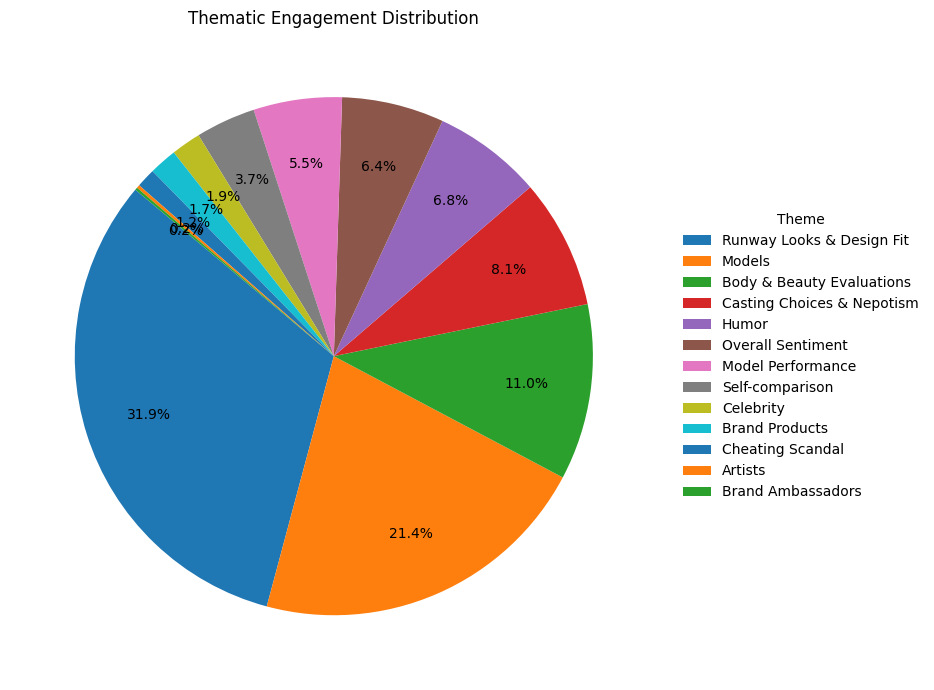


📁 Saved labeled top-144 Reddit comments to:
/content/drive/MyDrive/top144_reddit_comments_labeled_by_theme.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


CANDIDATE_LEADERS_PATHS = [
    Path("data/processed/reddit_opinion_leaders_144.csv"),
    Path("../data/processed/reddit_opinion_leaders_144.csv"),
]

leaders_path = next((p for p in CANDIDATE_LEADERS_PATHS if p.exists()), None)
if leaders_path is None:
    raise FileNotFoundError(
        "Could not find reddit_opinion_leaders_144.csv.\n"
        "Run the previous block first to generate it.\n"
        "Expected: data/processed/reddit_opinion_leaders_144.csv"
    )

leaders = pd.read_csv(leaders_path)
print(f"Loaded opinion leader list with {len(leaders):,} rows from:\n{leaders_path}")

# Required columns
REQUIRED = ["rank", "score", "stable_index", "body"]
missing_cols = [c for c in REQUIRED if c not in leaders.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns in leaders file: {missing_cols}. "
        f"Available columns: {list(leaders.columns)}"
    )

leaders["stable_index"] = pd.to_numeric(leaders["stable_index"], errors="coerce")
leaders = leaders.dropna(subset=["stable_index"]).copy()
leaders["stable_index"] = leaders["stable_index"].astype(int)

leaders["score"] = pd.to_numeric(leaders["score"], errors="coerce").fillna(0).astype(int)
leaders["body"] = leaders["body"].fillna("").astype(str).str.strip()

TOP_N = len(leaders)
print(f"Using TOP_N = {TOP_N} comments keyed by 'stable_index'.")

ranked = leaders.rename(columns={
    "score": "likeCount",
    "body": "comment"
}).copy()

ranked = ranked[["rank", "stable_index", "likeCount", "comment"]]

themes_by_index = {
    "Runway Looks & Design Fit": [
        77, 78, 79, 670, 83, 1205, 99, 629, 1177, 628, 958,
        116, 1274, 1460, 790, 97, 94, 630, 1261, 829, 656, 767,
        895, 1048, 657, 672, 1583, 691, 1027, 833, 109, 999, 1006,
        1279, 1291, 1214, 977, 1037, 794, 632, 655
    ],
    "Self-comparison": [1222, 1471, 1591, 1645, 1472],
    "Models": [
        82, 86, 88, 711, 80, 84, 91, 81, 93, 102, 87, 712, 90, 100, 101,
        765, 104, 92, 96, 120, 105, 98, 89, 855, 702, 106, 917, 95, 126,
        144, 110, 103, 922, 155, 107, 133, 830
    ],
    "Model Performance": [671, 1211, 673, 79, 1278, 125, 731, 925, 1214, 736, 1247, 169, 1212],
    "Casting Choices & Nepotism": [85, 83, 757, 754, 958, 753, 756, 999, 912, 755, 1255, 169],
    "Artists": [142],
    "Cheating Scandal": [1304, 853, 1502, 1620],
    "Brand Ambassadors": [1482],
    "Brand Products": [884, 767, 1311, 1577, 94, 1451],
    "Celebrity": [116, 954, 735, 1343, 1239],
    "Humor": [627, 1169, 1494, 1170, 657, 976, 1250, 631, 1472, 1102],
    "Body & Beauty Evaluations": [
        83, 757, 1177, 116, 737, 792, 769, 767, 895, 738, 1275, 655, 1503,
        115, 768, 1332, 833, 999, 766, 793, 854, 125, 977, 1132, 771
    ],
    "Overall Sentiment": [99, 118, 1184, 1440, 122, 131, 959, 985, 655, 1346]
}

index_to_themes = {}
for theme, indices in themes_by_index.items():
    for idx in indices:
        index_to_themes.setdefault(int(idx), []).append(theme)

def join_labels(idx: int) -> str:
    return ", ".join(index_to_themes.get(idx, []))

ranked["themes"] = ranked["stable_index"].apply(join_labels)

missing = ranked.loc[ranked["themes"].eq(""), "stable_index"].tolist()
if missing:
    print(f"⚠️ stable_index values in top-{TOP_N} with NO theme label:")
    print(sorted(missing))
else:
    print(f"✅ All top-{TOP_N} Reddit comments have at least one theme label.")

ranked["theme_list"] = ranked["themes"].apply(lambda x: x.split(", ") if x else [])
long = ranked.explode("theme_list").rename(columns={"theme_list": "theme"})
long = long[long["theme"] != ""]

counts = long.groupby("theme")["stable_index"].nunique().sort_values(ascending=False)
upvotes = long.groupby("theme")["likeCount"].sum().sort_values(ascending=False)

summary_df = pd.DataFrame({
    "Comments": counts,
    "Upvotes": upvotes,
    "Share of Upvotes (%)": (upvotes / upvotes.sum() * 100).round(1),
}).sort_values("Upvotes", ascending=False)

print("\n📊 THEME SUMMARY\n")
print(summary_df.to_string())

plt.figure(figsize=(10, 7))

wedges, texts, autotexts = plt.pie(
    summary_df["Upvotes"],
    labels=None,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75
)

plt.title("Thematic Engagement Distribution")

plt.legend(
    wedges,
    summary_df.index,
    title="Theme",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()


OUTPUT_DIR = Path("data/processed")
if not OUTPUT_DIR.exists():
    alt = Path("../data/processed")
    if alt.parent.exists():
        OUTPUT_DIR = alt
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUTPUT_DIR / "top144_reddit_comments_labeled_by_theme.csv"
ranked.to_csv(out_path, index=False, encoding="utf-8")
print(f"\n📁 Saved labeled top-{TOP_N} Reddit comments to:\n{out_path}")


In [ ]:
import pandas as pd
import textwrap
from pathlib import Path

CANDIDATE_PATHS = [
    Path("data/processed/top144_reddit_comments_labeled_by_theme.csv"),
    Path("../data/processed/top144_reddit_comments_labeled_by_theme.csv"),
]

reddit_labeled_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if reddit_labeled_path is None:
    raise FileNotFoundError(
        "Could not find top144_reddit_comments_labeled_by_theme.csv.\n"
        "Run the previous labeling block first.\n"
        "Expected: data/processed/top144_reddit_comments_labeled_by_theme.csv"
    )

df_labeled_comments = pd.read_csv(reddit_labeled_path)
print(f"✅ Loaded labeled Reddit comments from:\n{reddit_labeled_path}")


if "index" in df_labeled_comments.columns:
    df_labeled_comments = df_labeled_comments.rename(columns={"index": "stable_index"})


df_labeled_comments["themes"] = df_labeled_comments["themes"].apply(
    lambda x: [theme.strip() for theme in x.split(",")] if pd.notna(x) and x else []
)

all_unique_themes = sorted(
    {theme for sublist in df_labeled_comments["themes"] for theme in sublist}
)

MAX_WIDTH = 100

print("\nReddit Comments by Theme\n")

for theme in all_unique_themes:
    print(f"\n--- 🔵 Theme: {theme} ---")

    theme_comments = df_labeled_comments[
        df_labeled_comments["themes"].apply(lambda x: theme in x)
    ]

    if theme_comments.empty:
        print(f"  No comments found for '{theme}'.")
        continue

    theme_comments = theme_comments.sort_values(by="likeCount", ascending=False)

    for i, row in enumerate(theme_comments.itertuples(index=False), start=1):
        wrapped_comment = textwrap.fill(
            row.comment,
            width=MAX_WIDTH,
            break_long_words=False,
            replace_whitespace=False,
        )
        print(f"  {i}. 👍 {row.likeCount} upvotes  |  stable_index: {row.stable_index}")
        print(f"     {wrapped_comment}")
        print("-" * MAX_WIDTH)



Reddit Comments by Theme


--- 🔵 Theme: Artists ---
  1.👍 166 upvotes  |  stable_index: 142
     https://preview.redd.it/d1v6mlzhodvf1.jpeg?width=1600&format=pjpg&auto=webp&s=8771508531320a4d6553ad0dbe4544e3e0b7d32a
Karol G
----------------------------------------------------------------------------------------------------

--- 🔵 Theme: Body & Beauty Evaluations ---
  1.👍 1643 upvotes  |  stable_index: 655
     I think this brand is in their flop era. The outfits and designs don’t stand out, the makeup and
hair has been falling flat to me as well.
----------------------------------------------------------------------------------------------------
  2.👍 1430 upvotes  |  stable_index: 83
     I'm gonna get down voted to hell but to me the vibe is gorgeous women in very cheap-looking
underwhelming lingerie. VS can't seem to get it right. Plus the nepo element is tiring.
----------------------------------------------------------------------------------------------------
  3.👍 807 upvotes 

**3.0 Sentiment Analysis**

This includes a sentiment analysis on the overall dataset, as well as a manual review of 100 comments. Here, the doubtful or incorrect classifications are separated for closer review, before calculating the accuracy rate.  

In [ ]:
!pip install -q transformers torch

from transformers import pipeline
import pandas as pd
import torch
from pathlib import Path

df_reddit_new = pd.read_csv(CLEAN_REDDIT_DATA)
print(f"Comments loaded: {len(df_reddit_new):,}")

comments_df = df_reddit_new.copy()
comments_df["body"] = comments_df["body"].fillna("").astype(str)

MODEL_NAME = "j-hartmann/sentiment-roberta-large-english-3-classes"

use_cuda = torch.cuda.is_available()

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model=MODEL_NAME,
    device=0 if use_cuda else -1,
    torch_dtype=torch.float16 if use_cuda else None,
    truncation=True,
    max_length=512,
    padding=True
)

print("Model id2label:", sentiment_pipeline.model.config.id2label)

def normalize_label(lbl: str) -> str:
    lbl = str(lbl).strip()

    if lbl.upper().startswith("LABEL_"):
        idx = int(lbl.split("_")[-1])
        lbl = sentiment_pipeline.model.config.id2label.get(idx, lbl)

    return str(lbl).upper()

results = []
batch_size = 32

print("\nℕ Running sentiment analysis on entire dataset...\n")

for i in range(0, len(comments_df), batch_size):
    batch_texts = comments_df["body"].iloc[i:i + batch_size].tolist()

    batch_results = sentiment_pipeline(
        batch_texts,
        truncation=True,
        max_length=512,
        padding=True
    )

    results.extend(batch_results)
    print(
        f"Processed {min(i + batch_size, len(comments_df))}/{len(comments_df)} comments",
        end="\r"
    )

print("\n✅ Sentiment analysis complete!")

comments_df["sentiment_label"] = [normalize_label(r["label"]) for r in results]
comments_df["sentiment_score"] = [r["score"] for r in results]

# --- GitHub-ready output path ---
OUTPUT_DIR = Path("data/processed")
if not OUTPUT_DIR.exists():
    alt = Path("../data/processed")
    if alt.parent.exists():
        OUTPUT_DIR = alt
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / "sorted_reddit_comments_with_sentiment.csv"
comments_df.to_csv(output_path, index=False, encoding="utf-8")
print(f"\n💾 Enriched dataset saved to: {output_path}")

# Preview
comments_df[["body", "sentiment_label", "sentiment_score"]].head(5)


Comments loaded: 2,362


Some weights of the model checkpoint at j-hartmann/sentiment-roberta-large-english-3-classes were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Model id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}

ℕ Running sentiment analysis on entire dataset...

Processed 2362/2362 comments
✅ Sentiment analysis complete!

💾 Enriched dataset saved to: /content/drive/MyDrive/sorted_reddit_comments_with_sentiment.csv


,body,sentiment_label,sentiment_score
0,Very meh. \n\nToo much focus on the performers...,NEGATIVE,0.999006
1,I did not like the end at all. I think they sh...,NEGATIVE,0.999054
2,We have had better fashion shows tbh.. I watch...,NEGATIVE,0.999021
3,"It was better than the last one, like no slick...",NEGATIVE,0.999096
4,"Bring back glitz, more emphasis on showing the...",POSITIVE,0.999483


In [ ]:
import pandas as pd
from pathlib import Path

CANDIDATE_PATHS = [
    Path("data/processed/sorted_reddit_comments_with_sentiment.csv"),
    Path("../data/processed/sorted_reddit_comments_with_sentiment.csv"),
]

REDDIT_SENTIMENT = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if REDDIT_SENTIMENT is None:
    raise FileNotFoundError(
        "Could not find sorted_reddit_comments_with_sentiment.csv.\n"
        "Run the sentiment generation block first.\n"
        "Expected: data/processed/sorted_reddit_comments_with_sentiment.csv"
    )

df_reddit = pd.read_csv(REDDIT_SENTIMENT)
print(f"Loaded {len(df_reddit):,} Reddit rows from: {REDDIT_SENTIMENT}")


In [ ]:
import pandas as pd

df_sentiment = pd.read_csv(REDDIT_SENTIMENT)
pd.set_option("display.max_colwidth", None)
print(f"Loaded {len(df_sentiment):,} rows.")

df_sentiment[["body", "sentiment_label", "sentiment_score"]].head(100)


Loaded 2,362 rows.


,body,sentiment_label,sentiment_score
0,Very meh. \n\nToo much focus on the performers. Lots of stiff models.,NEGATIVE,0.999006
1,"I did not like the end at all. I think they should’ve had more looks with the angels walking around Missy Elliot like they did with the other artists. I felt like I was watching a concert at the end, it didn’t feel like VS at all.",NEGATIVE,0.999054
2,We have had better fashion shows tbh.. I watched the live stream on my TikTok & I didn’t like the camera angles. Plus I felt like the show went by wayyy too fast. I missed how the old performances in a straight runway rather than like the circle? Also I didn’t care for the VS PINK looks :/ I just really liked the old style fashion shows 😭 but that’s just my opinion! Lol,NEGATIVE,0.999021
3,"It was better than the last one, like no slick back pony tails but still a bit disappointing. I feel like the stylist completely changed…. It’s still nothing compared to the ones they did in like 2010-2018",NEGATIVE,0.999096
4,"Bring back glitz, more emphasis on showing the product versus layers, extravagant wings & a fantasy bra please 🪽😇",POSITIVE,0.999483
...,...,...,...
95,https://preview.redd.it/ef9q0rg11evf1.jpeg?width=1200&format=pjpg&auto=webp&s=0529330d6eb05431099b40c10b49466dc2b0231f\n\nYumi Nu,NEUTRAL,0.999068
96,https://preview.redd.it/rh3yiovwqdvf1.jpeg?width=1365&format=pjpg&auto=webp&s=14368d45cf2497ec55175ffa4938d22037787a1b\n\nSherry Shi,NEUTRAL,0.999109
97,"How come so many of these models are wearing bras that don't actually fit them?!\n\nChrist for a lingerie company, you'd think they could figure that out",NEGATIVE,0.998342
98,https://preview.redd.it/wwmds6iqqdvf1.jpeg?width=1366&format=pjpg&auto=webp&s=39fb88a15773ad6e653ac3c9572a820d95ade016\n\nMathilda Gvarliani,NEUTRAL,0.999084


In [ ]:
pd.set_option("display.max_colwidth", None)
indices = [4, 6, 11, 13, 20, 23, 39, 47, 59, 63, 72, 76]
df_sentiment.loc[indices, ["body", "sentiment_label", "sentiment_score"]]


,body,sentiment_label,sentiment_score
4,"Bring back glitz, more emphasis on showing the product versus layers, extravagant wings & a fantasy bra please 🪽😇",POSITIVE,0.999483
6,I love the karol G portion! She was giving the old sexy VS vibes and the black theme they did. I was super excited for madison beer but idk i didnt like the songs she was singing or something,NEGATIVE,0.976266
11,"Net improvement from 2024, but definitely room to grow. The Karol G portion was my favorite, got a glimpse into the ""very sexy"" red that VS is known for. I knew the looks for PINK would be unpopular, but since it is geared towards younger girls, I was happy to see more coverage. The end was just odd and random. No hate to Missy Elliot, she can put on an amazing performance, but the last section of a fashion show with no models?? With this said, no slickback in sight!",NEGATIVE,0.991486
13,Felt like performers line up could have been better tbh. Sabrina Carpenter would be perfect especially with the new album. Along with Katseye,POSITIVE,0.998150
20,Chop,NEUTRAL,0.993945
23,"It was an improvement from last year - I loved some looks , others not so much. & I agree with the other commenter that they need to go back to being beauty exclusive. The whole reason I admired Victoria’s Secret & loved watching the fashion shows growing up was bc they were selling a fantasy. & that was so fun to watch bc it isn’t the norm!",POSITIVE,0.998129
39,missy elliots performance was strangely long without any models,NEUTRAL,0.983957
47,The retro or 1990s early 2000s music towards the end was off since it wasn’t balanced with a strong fashion aesthetic ( in the end). Heavy focus on the musicians and not the models. I liked the consistency of the themes and the flirtyness. LOVED the masquerade mask wing. This was an example of the spontaneous and limited creative moments the show had. All in all the show was a spectacle.,NEGATIVE,0.819536
59,Completely agree with this.,POSITIVE,0.999081
63,"I agree. There was a noticeable difference in the walks, expression, and composure of pro models versus the people who seemed to be social media personalities. It was very hit or miss.",NEUTRAL,0.998569


**Review of Misclassifications**

This dataset includes a lot of detailed critical reviews of the show, sometimes forming very long paragraphs. In some cases comments provided a fairly balanced mixture of positive and negative feedback, where a neutral sentiment aligned better than an either negative or positive sentiment. When comments contained positive language, this was often classified as a positive sentiment, even though it was used to highlight this year’s inadequacy by drawing attention to missing desirable elements. Or comments stating to ‘agree’ with minimal context, are also classified as positive, even though this could be in reference to a negative opinion. These wrong classifications show how the model relies on the meaning of words, but has limited contextual awareness that contributes to the overall expressed sentiment.


*Accuracy report of 88%*

**3.1 Sentiment Popularity**

This reviews the popularity of each sentiment, first by reviewing their overall presence in the dataset, the top comments of each sentiment and the average like count per category.

✅ Loaded 2,362 Reddit comments with sentiment data


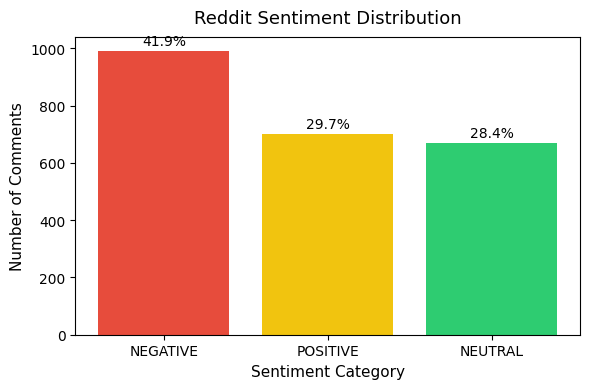


📊 Sentiment Breakdown:
NEGATIVE: 41.91% (990 comments)
POSITIVE: 29.72% (702 comments)
NEUTRAL: 28.37% (670 comments)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(REDDIT_SENTIMENT)
print(f"✅ Loaded {len(df):,} Reddit comments with sentiment data")

counts = df["sentiment_label"].value_counts()
percentages = (counts / counts.sum() * 100).round(2)


plt.figure(figsize=(6, 4))
bars = plt.bar(
    counts.index,
    counts.values,
    color=["#E74C3C", "#F1C40F", "#2ECC71"]
)

plt.title("Reddit Sentiment Distribution", fontsize=13, pad=10)
plt.xlabel("Sentiment Category", fontsize=11)
plt.ylabel("Number of Comments", fontsize=11)
plt.xticks(rotation=0)


for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


print("\n📊 Sentiment Breakdown:")
for label, pct in percentages.items():
    print(f"{label}: {pct:.2f}% ({counts[label]} comments)")


In [ ]:
import pandas as pd


df_sentiment = pd.read_csv(REDDIT_SENTIMENT)
df_sentiment.columns = df_sentiment.columns.str.lower()

def get_refined_sentiment(row):
    if (row["sentiment_label"] == "POSITIVE" or row["sentiment_label"] == "NEGATIVE") and row["sentiment_score"] < 0.6:
        return "NEUTRAL"
    else:
        return row["sentiment_label"]

df_sentiment["sentiment_label_refined"] = df_sentiment.apply(get_refined_sentiment, axis=1)

most_negative_upvoted = (
    df_sentiment[df_sentiment["sentiment_label_refined"].str.lower().str.contains("neg")]
    .sort_values("score", ascending=False)
    .head(15)
)

print("\n🔴 Top 15 Most-Upvoted Negative Comments:\n")
for _, row in most_negative_upvoted.iterrows():
    print(f"🖼 {row['body'][:500]}")
    print(f"   🔹 Sentiment: {row['sentiment_label_refined']} ({row['sentiment_score']:.3f}) | Upvotes: {row['score']}\n")


most_positive_upvoted = (
    df_sentiment[df_sentiment["sentiment_label_refined"].str.lower().str.contains("pos")]
    .sort_values("score", ascending=False)
    .head(15)
)

print("\n🟢 Top 15 Most-Upvoted Positive Comments:\n")
for _, row in most_positive_upvoted.iterrows():
    print(f"🖼 {row['body'][:500]}")
    print(f"   🔹 Sentiment: {row['sentiment_label_refined']} ({row['sentiment_score']:.3f}) | Upvotes: {row['score']}\n")


most_neutral_upvoted = (
    df_sentiment[df_sentiment["sentiment_label_refined"].str.lower().str.contains("neu")]
    .sort_values("score", ascending=False)
    .head(15)
)

print("\n🟡 Top 15 Most-Upvoted Neutral Comments:\n")
for _, row in most_neutral_upvoted.iterrows():
    print(f"🖼 {row['body'][:500]}")
    print(f"   🔹 Sentiment: {row['sentiment_label_refined']} ({row['sentiment_score']:.3f}) | Upvotes: {row['score']}\n")


🔴 Top 15 Most-Upvoted Negative Comments:

🖼 https://preview.redd.it/onjpdn3yvdvf1.jpeg?width=1206&format=pjpg&auto=webp&s=1473a7224b63a4ba550c4188f54d8f157675d93b

Who thought this was a good idea???
   🔹 Sentiment: NEGATIVE (0.878) | Upvotes: 4872

🖼 They did Gigi so dirty with that white outfit 😂😂 where are my girls arms
   🔹 Sentiment: NEGATIVE (0.981) | Upvotes: 2581

🖼 Is it just me or was Bella visibly struggling at the end? She looked like she was either going to pass out or the wings were too heavy 😪.
   🔹 Sentiment: NEGATIVE (0.999) | Upvotes: 2140

🖼 I think this brand is in their flop era. The outfits and designs don’t stand out, the makeup and hair has been falling flat to me as well.
   🔹 Sentiment: NEGATIVE (0.999) | Upvotes: 1643

🖼 I'm gonna get down voted to hell but to me the vibe is gorgeous women in very cheap-looking underwhelming lingerie. VS can't seem to get it right. Plus the nepo element is tiring.
   🔹 Sentiment: NEGATIVE (0.999) | Upvotes: 1430

🖼 that's li

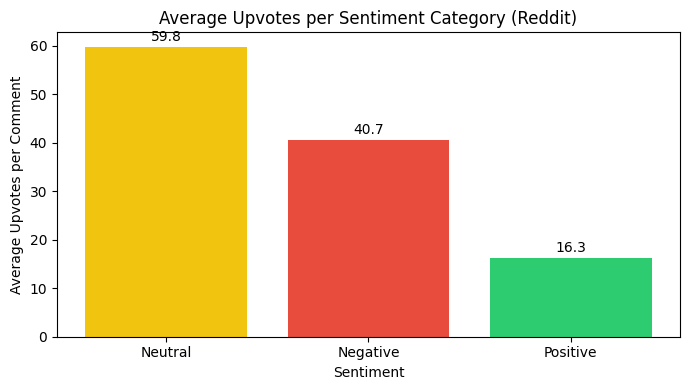


📊 Sentiment Popularity Summary
Neutral: 670 comments | Avg Upvotes: 59.8 | Total Upvotes: 40085
Negative: 990 comments | Avg Upvotes: 40.7 | Total Upvotes: 40271
Positive: 702 comments | Avg Upvotes: 16.3 | Total Upvotes: 11415


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv(REDDIT_SENTIMENT)

df.columns = df.columns.str.lower()


df = df.rename(columns={
    "body": "comment",
    "text": "comment",
    "score": "upvotes"
})


df["upvotes"] = pd.to_numeric(df["upvotes"], errors="coerce").fillna(0)


df["sentiment_label"] = df["sentiment_label"].astype(str).str.lower()


df["sentiment_label_plot"] = df["sentiment_label"].str.title()

sentiment_stats = (
    df.groupby("sentiment_label_plot")["upvotes"]
      .agg(["mean", "sum", "count"])
      .reset_index()
      .sort_values("mean", ascending=False)
)


color_map = {
    "Positive": "#2ECC71",
    "Neutral": "#F1C40F",
    "Negative": "#E74C3C"

}
colors = [color_map.get(label, "gray") for label in sentiment_stats["sentiment_label_plot"]]


plt.figure(figsize=(7, 4))
bars = plt.bar(sentiment_stats["sentiment_label_plot"], sentiment_stats["mean"], color=colors)
plt.title("Average Upvotes per Sentiment Category (Reddit)")
plt.ylabel("Average Upvotes per Comment")
plt.xlabel("Sentiment")


y_pad = sentiment_stats["mean"].max() * 0.01
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_pad,
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


print("\n📊 Sentiment Popularity Summary")
for _, row in sentiment_stats.iterrows():
    print(f"{row['sentiment_label_plot']}: {int(row['count'])} comments | "
          f"Avg Upvotes: {row['mean']:.1f} | Total Upvotes: {row['sum']:.0f}")


**4.0 Text Frequency Analysis**

This part includes an analysis of the most frequent words in the dataset. From the most frequent or thematically relevant words, the top 10 most liked comments are reviewed, to gain deeper contextual awareness.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import re

comments_df = pd.read_csv(CLEAN_REDDIT_DATA)

custom_stopwords = {
    's', 't', 'm', 're', 've', 'll', 'd', 'im', 'amp', 'u', 'ur', 'https', 'did',
    'co', 'com', 'www', 'like', 'also', 'one', 'would', 'could', 'get', 'didn',
     'don', 'just'
}


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


cleaned_comments = comments_df["body"].dropna().astype(str).apply(clean_text)


vectorizer = CountVectorizer(
    stop_words="english",
    token_pattern=r"\b[a-z]{2,}\b"
)


X = vectorizer.fit_transform(cleaned_comments)
words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

word_counts = pd.DataFrame({"word": words, "count": counts})


word_counts = word_counts[~word_counts["word"].isin(custom_stopwords)]


top_words = (
    word_counts
    .sort_values(by="count", ascending=False)
    .head(15)
    .reset_index(drop=True)
)


top_words.index = top_words.index + 1

print("Top 15 Most Used Words (Reddit):")
display(
    top_words.style.set_properties(
        **{
            "border": "1px solid black",
            "text-align": "left",
        }
    )
)


Top 15 Most Used Words (Reddit):


,word,count
1,models,271
2,vs,208
3,look,194
4,looks,177
5,wings,131
6,year,130
7,better,118
8,really,103
9,think,99
10,fashion,95


In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

TOP_N_WORDS = 15
TOP_N_COMMENTS = 15


text_col = "body"

for word in top_words["word"].head(TOP_N_WORDS):
    subset = comments_df[
        comments_df[text_col].str.contains(rf"\b{word}\b", case=False, regex=True)
    ]

    if subset.empty:
        continue

    top_comments = (
        subset.sort_values("score", ascending=False)
              .head(TOP_N_COMMENTS)[[text_col, "score", "stable_index"]]
              .reset_index(drop=True)
    )

    print(f"\n🔹 Top {TOP_N_COMMENTS} most-liked comments containing '{word}':\n")
    display(top_comments)


🔹 Top 15 most-liked comments containing 'models':



,body,score,stable_index
0,No hate to shorter folks but I saw Iris Law’s photo and immediately thought “this is why models are usually tall.”,807,757
1,"This makes me so mad as a plus size woman with a large chest. VS sells bras and they couldn’t make one to fit her perfectly? It’s ridiculous. She is gorgeous and this set does her no justice. \n\nSome of the super lean models also have bras that don’t fit their breasts properly. Victoria’s Secret, you had one job. Make lingerie that fits. Come on now.",787,1177
2,"How come so many of these models are wearing bras that don't actually fit them?!\n\nChrist for a lingerie company, you'd think they could figure that out",458,97
3,"The nepo baby obsession with being runway models when they aren’t built for it is just odd to me, they look like clowns.",337,756
4,"I wish models like this could look like they're having fun and not bored. I know, it's part of the deal. You need to look like you're over all of this. But the few that look like they're enjoying themselves are so much more charming and appealing than 30 women who look desperately disinterested.\n\nI dunno. ""This all sucks so bad"" face is less removed-goddess and more ""aw, everyone looks like this event sucks"" to me.",217,731
5,"Maybe I’m remembering wrong, but I feel like classic VS had all the models smiling and excited to be there?",175,925
6,"Yeah, several of these look quite uncomfortable even on their famous long-term models whom they should have perfect measurements of. Even if not they *are* the sample size so they should not look this painful! \n\nAlso, a lot of it looks like straight up cheap 2000s-2010s department store catalogue stuff. \n\n*",154,1278
7,"I feel the same. I used to be in absolute awe of these models. Now I feel nothing. I think it's social media, where everyone is modeling all of the time. It's not special or interesting anymore. It's just the same sh*t I see everywhere.",149,959
8,This is pretty common for fashion shows.Many years ago on ANTM Tyra said she wore a size 7 shoe for the VS show and she’s usually a 9.5 - they just don’t/can’t have that many shoes backstage - the models have to change fast and keeping them all similar sizes makes it easier to make quick adjustments to the outfits as needed which sometimes means putting on a totally different pair of shoes than originally styled/rehearsed 20 seconds before you walk,147,1291
9,"What gets me while watching this is that a large chunk of these models are mothers. \n\nAs a mom, I feel represented :) (albeit 50 lbs too heavy to walk that runway).",111,147



🔹 Top 15 most-liked comments containing 'vs':



,body,score,stable_index
0,I'm gonna get down voted to hell but to me the vibe is gorgeous women in very cheap-looking underwhelming lingerie. VS can't seem to get it right. Plus the nepo element is tiring.,1430,83
1,![gif](giphy|4KMduk6fuPJTi)\n\nI’m showing my age but the lingerie and costumes look cheap. I miss 90’s and 2000’s VS constantly. It started becoming cheap and tacky in the late 2000’s and early 2010’s when the Pink brand took over.,1141,99
2,"This makes me so mad as a plus size woman with a large chest. VS sells bras and they couldn’t make one to fit her perfectly? It’s ridiculous. She is gorgeous and this set does her no justice. \n\nSome of the super lean models also have bras that don’t fit their breasts properly. Victoria’s Secret, you had one job. Make lingerie that fits. Come on now.",787,1177
3,I know I was thinking about the poor woman who works SO hard to have a dream modeling opportunity at the VS show only to be stuck in this lol,699,628
4,"Maybe I'm just old, but none of this wows me. Has VS gone downhill. or have I just seen too much underwear in my life?",654,118
5,"Most of the VS fashion shows have a ton of tacky stuff, it seems it was minimal this year if this post was a good representation because this is the most tacky shown",326,630
6,the layered outfits are hideous. VS is so bad at layering even in their style guides,324,94
7,In 1996 I bought a beautiful VS velvet demi bra that lasted into the 2010’s. Not only were the design and materials pretty and flattering but they were of a much higher quality.,244,884
8,"It looks like the trim going down the center of her breasts is cutting in and giving her double boob on each side. VS has never exactly been *quality*, but you'd think they would bring it up a notch for this.",229,767
9,"I remember when VS sold quality clothing like jeans, heels, boots, sweaters, etc. I even remember they had decent makeup and swimsuits that lasted for over 10 years like you said. I bought a $50 wireless pushup bra last year that I barely wear and it’s already pilling.",215,1311



🔹 Top 15 most-liked comments containing 'look':



...

,body,score,stable_index
0,Bella’s second walk. The first one is pictured in this post.,183,1211
1,This is pretty common for fashion shows.Many years ago on ANTM Tyra said she wore a size 7 shoe for the VS show and she’s usually a 9.5 - they just don’t/can’t have that many shoes backstage - the models have to change fast and keeping them all similar sizes makes it easier to make quick adjustments to the outfits as needed which sometimes means putting on a totally different pair of shoes than originally styled/rehearsed 20 seconds before you walk,147,1291
2,"What gets me while watching this is that a large chunk of these models are mothers. \n\nAs a mom, I feel represented :) (albeit 50 lbs too heavy to walk that runway).",111,147
3,Lmao why is there a t shirt UNDER a bra. Imagine getting to walk for VS and they put you in that OR worst any of the pink outfits I’d die.,77,1689
4,Her walk wasn’t it at all and she’s like no I’d didn’t prepare. She’s gorgeous but this is no fashion show walk,70,1051
5,I love Alex and how beautiful she walks however I was thinking like why is she giving advice on the earlier interview saying eat that burger or something while she’s just so so underweight.. it’s just crazy.\n\n\nI do love her and was excited seeing her walk again. She’s absolutely stunning,41,1414
6,Her walk looked ridiculous I’m sorry,32,1609
7,I don’t think singers should do a walk or have wings tbh 😬,32,2127
8,If you’re going to have 4 walk at once make them walk in sync,31,1707
9,"Some of those wings look so heavy! Imagine having to walk on that slippery floor in heels while balancing them. I feel like they can make nice, light wings and skip those monstrosities.",30,128



🔹 Top 15 most-liked comments containing 'outfits':



,body,score,stable_index
0,"I think this brand is in their flop era. The outfits and designs don’t stand out, the makeup and hair has been falling flat to me as well.",1643,655
1,"some of these outfits are meh, but they all look absolutely stunning.\n\nKinda off topic, but also on topic, I loved Gigis post this morning, of her daughter’s school lunch, saying VSFS mornings are different this time around.\n\nhttps://preview.redd.it/m1gaop6apdvf1.jpeg?width=1290&format=pjpg&auto=webp&s=ab307a05e4c3f28a244aed711a0dc79590eb6524",566,116
2,the layered outfits are hideous. VS is so bad at layering even in their style guides,324,94
3,This is pretty common for fashion shows.Many years ago on ANTM Tyra said she wore a size 7 shoe for the VS show and she’s usually a 9.5 - they just don’t/can’t have that many shoes backstage - the models have to change fast and keeping them all similar sizes makes it easier to make quick adjustments to the outfits as needed which sometimes means putting on a totally different pair of shoes than originally styled/rehearsed 20 seconds before you walk,147,1291
4,It looks like they’re desperately trying to make the outfits less revealing.,129,632
5,Lmao why is there a t shirt UNDER a bra. Imagine getting to walk for VS and they put you in that OR worst any of the pink outfits I’d die.,77,1689
6,"This might be my unpopular opinion but most of the outfits look tacky, the makeup isn't great (where are the days when we used to get the voluminous bouncy hair on angels?). This show wasn't great, they are trying hard to bounce back but its not happening!",68,149
7,"Jasmine Tookes looks AMAZING.\n\nI HATE almost everything else. Why are the outfits so godawful ugly this year? Messy layered underwear? Who the hell is this for? And some of the wings are dreadful. Bottom tier year, OMG. 😱",59,130
8,"The pink outfits are diabolical 💀 pink was never sweatpants and primark shorts lol, it’s still glam and amazing just more teen girl coded",53,1727
9,"The pink outfits were not it, even the walks were meh at best.",33,1730



🔹 Top 15 most-liked comments containing 'beautiful':



,body,score,stable_index
0,In 1996 I bought a beautiful VS velvet demi bra that lasted into the 2010’s. Not only were the design and materials pretty and flattering but they were of a much higher quality.,244,884
1,Anok Yai is another world kind of beautiful.,203,115
2,This woman is the epitome of a goddess. She is so unbelievably beautiful.,171,793
3,"Wait, jasmine tookes me emotional. I’ve never seen a pregnant model on a runway before. She looks beautiful!!! 🥹",150,125
4,she’s so fine and i actually like the simplicity of this. the wings are beautiful. none of the bras fitting right is really irking me though.,149,977
5,ethereal. She’s so beautiful it hurts 😫,101,1288
6,The two nepo babies looking like shit not surprising. Jude and Kate's spawn. Everyone else looks stunning. Victoria secret should have been like this keep og angels and allow beautiful plus sized models.,99,161
7,She is sooo beautiful,96,739
8,Beautiful! But a swim suit over a bra & panties? What the hell is going on here,81,1114
9,I'm devastated that He Sui wasn't back this year. I have vivid memories of seeing her at the VS show in high school and being convinced she was the most beautiful woman in the world\n\nhttps://preview.redd.it/rz5ykubgghvf1.jpeg?width=407&format=pjpg&auto=webp&s=ce5452c32ae8a9500baa3047573ec2f339b62f3e,54,1331


**5.0 Topic Modelling**

This part conducts topic modelling on the entire dataset using semantic embeddings, which capture the meaning of the word and don’t rely exclusively on frequency patterns.

In [ ]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan nltk

import pandas as pd
import nltk
import re
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords


df_reddit = pd.read_csv(CLEAN_REDDIT_DATA)
print(f"✅ Loaded Reddit dataset with {len(df_reddit):,} rows")


text_col = next((c for c in ["body", "comment", "text", "content"] if c in df_reddit.columns), None)
if text_col is None:
    raise ValueError("❌ No text column found (expected body, comment, text, or content).")


df_reddit[text_col] = df_reddit[text_col].fillna("").astype(str)


df_reddit = df_reddit[df_reddit[text_col].str.strip().ne("")].copy()
print(f"🧹 Kept {len(df_reddit):,} comments")



nltk.download("stopwords")
stopwords_en = set(stopwords.words("english")) | {
    "https", "http", "www", "com", "jpg", "removed", "deleted", "amp",
    "vs", "victoria", "secret"
}
stopwords_en = list(stopwords_en)


vectorizer_model = CountVectorizer(
    stop_words=stopwords_en,
    token_pattern=r"[A-Za-z']{3,}",
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2)
)


embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="english",
    min_topic_size=40,
    calculate_probabilities=True,
    verbose=True
)


texts = df_reddit[text_col].tolist()
topics, probs = topic_model.fit_transform(texts)
df_reddit["bertopic_topic"] = topics


pd.set_option("display.max_colwidth", None)
topic_info = topic_model.get_topic_info()
print(f"\n📊 Topic overview (all {len(topic_info)} topics):")
print(topic_info.to_string(index=False))


all_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()

print("\n🔍 Inspecting ALL topics (excluding -1 outliers) with example comments:")
sample_n = 15

for t in all_topics:
    print("\n" + "=" * 60)
    print(f"🧩 Topic {t}")
    print("Top words:", topic_model.get_topic(t))
    print("\n💬 Sample comments:")
    sample_comments = df_reddit.loc[df_reddit["bertopic_topic"] == t, text_col].head(sample_n)
    for i, c in enumerate(sample_comments, start=1):
        print(f"{i:2d}. {c}")



✅ Loaded Reddit dataset with 2,362 rows
🧹 Kept 2,362 comments


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2025-12-31 23:42:24,185 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/74 [00:00<?, ?it/s]

2025-12-31 23:42:27,144 - BERTopic - Embedding - Completed ✓
2025-12-31 23:42:27,145 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-31 23:43:05,323 - BERTopic - Dimensionality - Completed ✓
2025-12-31 23:43:05,325 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-31 23:43:05,578 - BERTopic - Cluster - Completed ✓
2025-12-31 23:43:05,586 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-31 23:43:05,682 - BERTopic - Representation - Completed ✓
2025-12-31 23:43:05,816 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



📊 Topic overview (all 5 topics):
 Topic  Count                         Name                                                                                    Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          